# Single Qubit State Exploration

**Purpose:** 
This notebook is my independent exploration of Qiskit's `Statevector` and `Operator` classes, based on the concepts from Lesson 1. 

I want to:
1. Manually build superposition states using `NumPy`.
2. Verify their validity using Qiskit.
3. Experimentally test the probability distributions using `sample_counts`.
4. Observe what happens when I apply operators to these states.

In [4]:
# Import the tools we need
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

# 1. Let's create the |+> state mathematically: [1/sqrt(2), 1/sqrt(2)]
# We use NumPy arrays for the raw math
plus_array = np.array([1/np.sqrt(2), 1/np.sqrt(2)])

# 2. Convert our raw math into a Qiskit Statevector object
plus_state = Statevector(plus_array)

# Let's display it nicely using LaTeX rendering
display(plus_state.draw('latex'))

# 3. An important concept: does the probability sum to 1?
# Qiskit can verify if our math created a physically valid quantum state:
print("Is this a valid quantum state?", plus_state.is_valid())

<IPython.core.display.Latex object>

Is this a valid quantum state? True


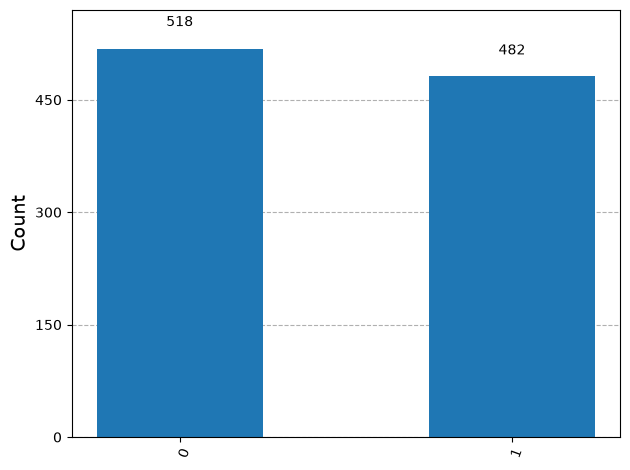

In [5]:
# 4. Experimental verification of probability
# The math says |+> has a 50% chance of being 0 and 50% chance of being 1.
# Let's simulate measuring this exact state 1,000 times to see if reality (or simulation) matches the math!

statistics = plus_state.sample_counts(1000)
display(plot_histogram(statistics))

## Evolving States with Operators

A quantum state isn't very useful if we can't change it. We use **Unitary Operators** (matrices) to evolve our state vectors. 

Let's test two fundamental operators:
1. **The X Operator (NOT gate):** This should flip a $|0\rangle$ to a $|1\rangle$.
2. **The Z Operator (Phase flip):** Let's see what this does to our $|+\rangle$ superposition state!

In [6]:
from qiskit.quantum_info import Operator

# 1. Define the X matrix: [[0, 1], [1, 0]]
X_op = Operator([
    [0, 1], 
    [1, 0]
])

# 2. Define the starting state |0>
ket0 = Statevector([1, 0])
print("Original state:")
display(ket0.draw('latex'))

# 3. Evolve the state using the X operator
state_after_x = ket0.evolve(X_op)

print("State after applying X:")
display(state_after_x.draw('latex'))

Original state:


<IPython.core.display.Latex object>

State after applying X:


<IPython.core.display.Latex object>